# Эксперимент с RuBERT frozen encoder для multi-label классификации

Этот ноутбук обучает multi-label классификатор отзывов на базе RuBERT: encoder используется как замороженный извлекатель признаков, а сверху обучается классификационная голова.

## Зачем нужен ноутбук

Этот эксперимент нужен как отдельная нейросетевая baseline-модель, которую можно сравнить с embedding-подходом.

В embedding-подходе эмбеддинги строятся отдельными sentence-transformer моделями, а сверху обучаются классические классификаторы.  
Здесь используется RuBERT encoder и обучаемая линейная голова для предсказания нескольких labels.

## Входные данные

```text
train dataset:
data/labeled/wb_feedbacks_ChatGpt_markup_from_synthetic_gpt5_V_2/
chatgpt_labeled_reviews_mvp_combined.csv
```

```text
golden set:
data/labeled/wb_feedbacks_manual_check_random_gpt5_prompt_test_v5/
manual_check_random_by_class_gpt5_relabelled.csv
```

## Что делает ноутбук

1. Загружает train dataset и golden set.
2. Делит train dataset на train/validation.
3. Извлекает признаки текстов через RuBERT encoder.
4. Замораживает encoder и обучает только классификационную голову.
5. Подбирает отдельные thresholds по validation set.
6. Сравнивает baseline `threshold = 0.5` и thresholded-версию.
7. Оценивает качество на golden set.
8. Сохраняет метрики, модель, thresholds и графики.

## Используемая модель

```text
DeepPavlov/rubert-base-cased
```

Ссылка:

```text
https://huggingface.co/DeepPavlov/rubert-base-cased
```

## Выходные данные

```text
data/labeled/rubert_frozen_encoder_experiment/
```

Основные файлы:

```text
summary_metrics_rubert_frozen_encoder.csv
per_class_metrics_rubert_frozen_encoder.csv
rubert_frozen_encoder_thresholds.csv
training_history.csv
```

Также сохраняются:

```text
features_cache/
trained_model/rubert_frozen_linear_head.pt
plots/
```

## Роль в пайплайне

```text
GPT-5 train dataset + golden set
        ↓
rubert_frozen_encoder_multilabel_reviews.ipynb
        ↓
RuBERT frozen encoder + linear head
        ↓
сравнение с embedding-классификаторами
```

Этот ноутбук нужен, чтобы проверить, дает ли специализированная RuBERT-модель качество лучше или хуже, чем подход с готовыми эмбеддингами и классическими классификаторами.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# Если запускаешь в Colab / чистом окружении, раскомментируй установку.
# !pip -q install -U transformers accelerate scikit-learn pandas numpy matplotlib tqdm joblib

In [3]:
import ast
import gc
import json
import os
import random
import re
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import precision_recall_fscore_support, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


## 1. Конфигурация

In [4]:
# === УКАЖИ СВОЙ ПУТЬ ===
# Если в твоем старом ноутбуке уже есть переменная labeled_dir, можно оставить как есть.
try:
    labeled_dir
except NameError:
    labeled_dir = "/content/drive/MyDrive/MLops_project/project/data/labeled"  # поменяй на свой путь

labeled_dir = Path(labeled_dir)

GOLDEN_PATH = labeled_dir / "wb_feedbacks_manual_check_random_gpt5_prompt_test_v5" / "manual_check_random_by_class_gpt5_relabelled.csv"
TRAIN_PATH = labeled_dir / "wb_feedbacks_ChatGpt_markup_from_synthetic_gpt5_V_2" / "chatgpt_labeled_reviews_mvp_combined.csv"

OUTPUT_DIR = labeled_dir / "rubert_frozen_encoder_experiment"
FEATURE_DIR = OUTPUT_DIR / "features_cache"
MODEL_DIR = OUTPUT_DIR / "trained_model"
PLOTS_DIR = OUTPUT_DIR / "plots"

for d in [OUTPUT_DIR, FEATURE_DIR, MODEL_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Модель RuBERT.
# Это именно frozen encoder: базовый RuBERT не обучаем, обучаем только голову сверху.
RUBERT_MODEL_NAME = "DeepPavlov/rubert-base-cased"

# Токенизация / извлечение признаков
MAX_LENGTH = 192
ENCODE_BATCH_SIZE = 32

# Обучение головы
VAL_SIZE = 0.20
HEAD_BATCH_SIZE = 32
EPOCHS = 40
LR = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.25
PATIENCE = 7

# Подбор thresholds
N_THRESHOLD_GRID = 91  # пороги от 0.05 до 0.95

# Удалять exact-overlap между train и golden, чтобы не было утечки
DROP_EXACT_TRAIN_TEST_LEAKAGE = True

print("TRAIN_PATH:", TRAIN_PATH)
print("GOLDEN_PATH:", GOLDEN_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

TRAIN_PATH: /content/drive/MyDrive/MLops_project/project/data/labeled/wb_feedbacks_ChatGpt_markup_from_synthetic_gpt5_V_2/chatgpt_labeled_reviews_mvp_combined.csv
GOLDEN_PATH: /content/drive/MyDrive/MLops_project/project/data/labeled/wb_feedbacks_manual_check_random_gpt5_prompt_test_v5/manual_check_random_by_class_gpt5_relabelled.csv
OUTPUT_DIR: /content/drive/MyDrive/MLops_project/project/data/labeled/rubert_frozen_encoder_experiment


## 2. Утилиты для чтения и нормализации labels

In [5]:
def read_csv_smart(path: Path) -> pd.DataFrame:
    """Читает csv с несколькими частыми кодировками."""
    encodings = ["utf-8", "utf-8-sig", "cp1251"]
    last_error = None
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception as e:
            last_error = e
    raise last_error


def normalize_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def parse_labels_cell(x):
    """Парсит labels из list / json / python-list-string / строки через ; | , ."""
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []

    if isinstance(x, (list, tuple, set)):
        raw = list(x)
    else:
        s = str(x).strip()
        if not s or s.lower() in {"nan", "none", "null", "[]"}:
            return []

        parsed = None
        if s.startswith("[") or s.startswith("{"):
            for parser in (json.loads, ast.literal_eval):
                try:
                    parsed = parser(s)
                    break
                except Exception:
                    pass

        if isinstance(parsed, dict):
            if "labels" in parsed:
                raw = parsed["labels"]
            elif "new_labels" in parsed:
                raw = parsed["new_labels"]
            else:
                raw = list(parsed.values())
        elif isinstance(parsed, (list, tuple, set)):
            raw = list(parsed)
        elif parsed is not None:
            raw = [parsed]
        else:
            # fallback: делим строку по частым разделителям
            raw = re.split(r"[;|]", s)
            if len(raw) == 1 and "," in s:
                raw = [part.strip() for part in s.split(",")]

    labels = []
    for item in raw:
        if item is None or (isinstance(item, float) and pd.isna(item)):
            continue
        item = str(item).strip().strip('"').strip("'")
        item = re.sub(r"\s+", " ", item)
        if item:
            labels.append(item)

    # Убираем дубли с сохранением порядка
    seen = set()
    unique = []
    for label in labels:
        if label not in seen:
            seen.add(label)
            unique.append(label)

    return unique


def find_column(df: pd.DataFrame, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    raise ValueError(f"Не нашел колонку. Кандидаты: {candidates}. Есть: {list(df.columns)}")


def safe_name(s: str) -> str:
    s = str(s)
    s = re.sub(r"[^a-zA-Z0-9а-яА-ЯёЁ_.-]+", "_", s)
    return s.strip("_")

## 3. Загрузка train и golden set

In [6]:
train_df = read_csv_smart(TRAIN_PATH)
golden_df = read_csv_smart(GOLDEN_PATH)

print("Train shape:", train_df.shape)
print("Golden shape:", golden_df.shape)
print("Train columns:", list(train_df.columns))
print("Golden columns:", list(golden_df.columns))

Train shape: (1820, 9)
Golden shape: (150, 17)
Train columns: ['отзыв', 'old_labels', 'new_labels', 'labels', 'source_type', 'source_files', 'source_row_ids', 'old_labels_str', 'new_labels_str']
Golden columns: ['manual_check_id', 'class_for_check', 'source_type', 'отзыв', 'old_labels', 'new_labels', 'correct_labels', 'old_labels_str', 'new_labels_str', 'correct_labels_str', 'labels_changed', 'new_equals_correct', 'comment', 'source_class_file', 'labels', 'labels_str', 'is_correct']


In [7]:
# Golden set: строго по твоему описанию — колонки 'отзыв', 'new_labels'.
GOLDEN_TEXT_COL = "отзыв"
GOLDEN_LABEL_COL = "new_labels"

if GOLDEN_TEXT_COL not in golden_df.columns:
    raise ValueError(f"В golden set нет колонки {GOLDEN_TEXT_COL!r}. Есть: {list(golden_df.columns)}")
if GOLDEN_LABEL_COL not in golden_df.columns:
    raise ValueError(f"В golden set нет колонки {GOLDEN_LABEL_COL!r}. Есть: {list(golden_df.columns)}")

# Train: ожидаем 'отзыв' и 'labels', но делаем fallback на частые варианты.
TRAIN_TEXT_COL = find_column(train_df, ["отзыв", "review", "review_text", "text", "feedback", "comment"])
TRAIN_LABEL_COL = find_column(train_df, ["labels", "new_labels", "label", "target", "classes"])

print("TRAIN_TEXT_COL:", TRAIN_TEXT_COL)
print("TRAIN_LABEL_COL:", TRAIN_LABEL_COL)
print("GOLDEN_TEXT_COL:", GOLDEN_TEXT_COL)
print("GOLDEN_LABEL_COL:", GOLDEN_LABEL_COL)

TRAIN_TEXT_COL: отзыв
TRAIN_LABEL_COL: labels
GOLDEN_TEXT_COL: отзыв
GOLDEN_LABEL_COL: new_labels


In [8]:
train = train_df[[TRAIN_TEXT_COL, TRAIN_LABEL_COL]].copy()
train.columns = ["text", "labels"]
train["text"] = train["text"].map(normalize_text)
train["labels"] = train["labels"].map(parse_labels_cell)
train = train[(train["text"] != "") & (train["labels"].map(len) > 0)].copy()

golden = golden_df[[GOLDEN_TEXT_COL, GOLDEN_LABEL_COL]].copy()
golden.columns = ["text", "labels"]
golden["text"] = golden["text"].map(normalize_text)
golden["labels"] = golden["labels"].map(parse_labels_cell)
golden = golden[(golden["text"] != "") & (golden["labels"].map(len) > 0)].copy()

# Убираем точные дубли внутри train и golden.
train = train.drop_duplicates(subset=["text"]).reset_index(drop=True)
golden = golden.drop_duplicates(subset=["text"]).reset_index(drop=True)

# Важно: если golden попал в train, это утечка. По умолчанию удаляем exact match из train.
if DROP_EXACT_TRAIN_TEST_LEAKAGE:
    golden_texts = set(golden["text"])
    before = len(train)
    train = train[~train["text"].isin(golden_texts)].reset_index(drop=True)
    print(f"Удалено exact-overlap из train по тексту: {before - len(train)}")

print("Train after cleaning:", train.shape)
print("Golden after cleaning:", golden.shape)

train.head()

Удалено exact-overlap из train по тексту: 87
Train after cleaning: (1733, 2)
Golden after cleaning: (147, 2)


,text,labels
0,Не держится. Какая то пленка …,[Проблема с качеством товара]
1,"Куртка хорошая, качественная! Замок правда зли...",[Проблема с качеством товара]
2,"Задумка не плохая, но качество материала не по...",[Проблема с качеством товара]
3,"Остаются темные потеки от конденсата,которые н...",[Проблема с качеством товара]
4,"К сожалению, пришли разбитые. Поэтому отказ",[Проблема с качеством товара]


In [9]:
all_labels = sorted(set(label for labels in pd.concat([train["labels"], golden["labels"]]) for label in labels))
print("Всего классов:", len(all_labels))
for i, label in enumerate(all_labels, 1):
    print(f"{i:02d}. {label}")

mlb = MultiLabelBinarizer(classes=all_labels)
Y_all_train = mlb.fit_transform(train["labels"])
Y_golden = mlb.transform(golden["labels"])

label_names = list(mlb.classes_)

train_counts = pd.Series(Y_all_train.sum(axis=0), index=label_names).sort_values(ascending=False)
golden_counts = pd.Series(Y_golden.sum(axis=0), index=label_names).sort_values(ascending=False)

counts_df = pd.DataFrame({
    "train_support": train_counts,
    "golden_support": golden_counts,
}).fillna(0).astype(int)

counts_df

Всего классов: 9
01. Другая проблема
02. Несоответствие карточке товара
03. Положительный / нейтральный отзыв
04. Проблема доставки / получения
05. Проблема с возвратом
06. Проблема с качеством товара
07. Проблема с комплектацией / упаковкой
08. Проблема с размером / посадкой
09. Цена / ценность


,train_support,golden_support
Другая проблема,66,5
Несоответствие карточке товара,231,32
Положительный / нейтральный отзыв,201,21
Проблема доставки / получения,205,18
Проблема с возвратом,230,21
Проблема с качеством товара,598,43
Проблема с комплектацией / упаковкой,421,24
Проблема с размером / посадкой,210,23
Цена / ценность,183,17


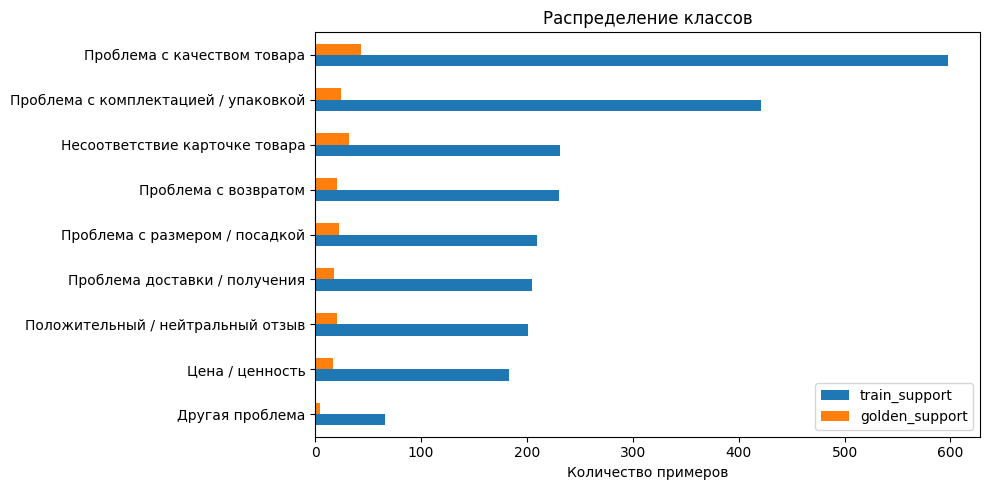

In [10]:
# Быстрый график распределения классов в train и golden.
ax = counts_df.sort_values("train_support", ascending=True).plot(
    kind="barh",
    figsize=(10, max(5, 0.35 * len(counts_df))),
    title="Распределение классов"
)
ax.set_xlabel("Количество примеров")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "class_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Train / validation split

In [11]:
# Validation нужен только для early stopping и подбора thresholds.
# Golden set не используется для подбора порогов.
indices = np.arange(len(train))

train_idx, val_idx = train_test_split(
    indices,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
)

train_part = train.iloc[train_idx].reset_index(drop=True)
val_part = train.iloc[val_idx].reset_index(drop=True)

Y_train = Y_all_train[train_idx]
Y_val = Y_all_train[val_idx]

print("Train split:", train_part.shape, Y_train.shape)
print("Val split:", val_part.shape, Y_val.shape)
print("Golden:", golden.shape, Y_golden.shape)

Train split: (1386, 2) (1386, 9)
Val split: (347, 2) (347, 9)
Golden: (147, 2) (147, 9)


## 5. Извлечение CLS-признаков из замороженного RuBERT

In [12]:
def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).type_as(last_hidden_state)
    summed = (last_hidden_state * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts


def extract_rubert_features(
    texts,
    split_name: str,
    model_name: str = RUBERT_MODEL_NAME,
    max_length: int = MAX_LENGTH,
    batch_size: int = ENCODE_BATCH_SIZE,
    pooling: str = "cls",  # "cls" или "mean"
):
    """
    Извлекает признаки из замороженного RuBERT и кеширует в .npy.

    pooling='cls':
        берем embedding CLS-токена.

    pooling='mean':
        усредняем токены по attention_mask.
    """
    cache_path = FEATURE_DIR / (
        f"{safe_name(model_name)}__{split_name}__n{len(texts)}"
        f"__maxlen{max_length}__pool{pooling}.npy"
    )

    if cache_path.exists():
        print(f"Загружаю RuBERT features из кеша: {cache_path}")
        return np.load(cache_path)

    print(f"Считаю RuBERT features для {split_name}: n={len(texts)}")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    encoder = AutoModel.from_pretrained(model_name).to(device)
    encoder.eval()

    features = []

    with torch.no_grad():
        for start in tqdm(range(0, len(texts), batch_size), desc=f"Encoding {split_name}"):
            batch_texts = list(texts[start:start + batch_size])
            inputs = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt",
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}
            outputs = encoder(**inputs)

            if pooling == "cls":
                batch_features = outputs.last_hidden_state[:, 0, :]
            elif pooling == "mean":
                batch_features = mean_pooling(outputs.last_hidden_state, inputs["attention_mask"])
            else:
                raise ValueError("pooling должен быть 'cls' или 'mean'")

            features.append(batch_features.detach().cpu().numpy().astype("float32"))

    features = np.vstack(features)
    np.save(cache_path, features)
    print(f"Сохранил RuBERT features: {cache_path}")
    print("Features shape:", features.shape)

    del encoder
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return features

In [13]:
# CLS-признаки считаются один раз и потом берутся из кеша.
X_train = extract_rubert_features(train_part["text"].tolist(), split_name="train")
X_val = extract_rubert_features(val_part["text"].tolist(), split_name="val")
X_golden = extract_rubert_features(golden["text"].tolist(), split_name="golden")

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_golden:", X_golden.shape)

Считаю RuBERT features для train: n=1386


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.65M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Сохранил RuBERT features: /content/drive/MyDrive/MLops_project/project/data/labeled/rubert_frozen_encoder_experiment/features_cache/DeepPavlov_rubert-base-cased__val__n347__maxlen192__poolcls.npy
Features shape: (347, 768)
Считаю RuBERT features для golden: n=147


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding golden:   0%|          | 0/5 [00:00<?, ?it/s]

Сохранил RuBERT features: /content/drive/MyDrive/MLops_project/project/data/labeled/rubert_frozen_encoder_experiment/features_cache/DeepPavlov_rubert-base-cased__golden__n147__maxlen192__poolcls.npy
Features shape: (147, 768)
X_train: (1386, 768)
X_val: (347, 768)
X_golden: (147, 768)


## 6. Модель головы и обучение

In [14]:
class LinearMultilabelHead(nn.Module):
    def __init__(self, input_dim: int, n_labels: int, dropout: float = 0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(input_dim, n_labels),
        )

    def forward(self, x):
        return self.net(x)


def make_loader(X, Y, batch_size=32, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32)
    Y_t = torch.tensor(Y, dtype=torch.float32)
    ds = TensorDataset(X_t, Y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def predict_proba_head(model, X, batch_size=256):
    model.eval()
    probs = []
    dummy_y = np.zeros((len(X), len(label_names)))
    loader = make_loader(X, dummy_y, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(device)
            logits = model(xb)
            batch_probs = torch.sigmoid(logits).detach().cpu().numpy()
            probs.append(batch_probs)

    return np.vstack(probs)


def evaluate_binary_predictions(y_true, y_pred, label_names, experiment_name):
    p, r, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        average=None,
        zero_division=0,
    )

    per_class = pd.DataFrame({
        "experiment": experiment_name,
        "class": label_names,
        "precision": p,
        "recall": r,
        "f1": f1,
        "support": support,
        "true_rate_golden": np.asarray(y_true).mean(axis=0),
        "predicted_rate_golden": np.asarray(y_pred).mean(axis=0),
    })

    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="micro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    summary = {
        "experiment": experiment_name,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "micro_precision": micro_p,
        "micro_recall": micro_r,
        "micro_f1": micro_f1,
        "weighted_precision": weighted_p,
        "weighted_recall": weighted_r,
        "weighted_f1": weighted_f1,
    }

    return per_class, summary


def compute_pos_weight(Y):
    # pos_weight = negative / positive для BCEWithLogitsLoss.
    # Клип нужен, чтобы редкие классы не ломали обучение слишком большими весами.
    pos = Y.sum(axis=0)
    neg = len(Y) - pos
    pos_weight = neg / np.clip(pos, 1, None)
    pos_weight = np.clip(pos_weight, 1.0, 10.0)
    return torch.tensor(pos_weight, dtype=torch.float32, device=device)

In [15]:
input_dim = X_train.shape[1]
n_labels = len(label_names)

model = LinearMultilabelHead(
    input_dim=input_dim,
    n_labels=n_labels,
    dropout=DROPOUT,
).to(device)

pos_weight = compute_pos_weight(Y_train)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

train_loader = make_loader(X_train, Y_train, batch_size=HEAD_BATCH_SIZE, shuffle=True)

best_val_macro_f1 = -1.0
best_state = None
best_epoch = 0
patience_counter = 0

history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(xb)

    train_loss = total_loss / len(X_train)

    val_probs = predict_proba_head(model, X_val)
    val_pred_05 = (val_probs >= 0.5).astype(int)
    val_macro_f1 = f1_score(Y_val, val_pred_05, average="macro", zero_division=0)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_macro_f1_at_0_5": val_macro_f1,
    })

    print(f"Epoch {epoch:02d}/{EPOCHS} | loss={train_loss:.4f} | val_macro_f1@0.5={val_macro_f1:.4f}")

    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f"Early stopping на эпохе {epoch}. Лучший epoch={best_epoch}, val_macro_f1={best_val_macro_f1:.4f}")
        break

model.load_state_dict(best_state)
history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False, encoding="utf-8-sig")
history_df.tail()

Epoch 01/40 | loss=1.0760 | val_macro_f1@0.5=0.3316
Epoch 02/40 | loss=0.9845 | val_macro_f1@0.5=0.3674
Epoch 03/40 | loss=0.9314 | val_macro_f1@0.5=0.4140
Epoch 04/40 | loss=0.8989 | val_macro_f1@0.5=0.3897
Epoch 05/40 | loss=0.8662 | val_macro_f1@0.5=0.4562
Epoch 06/40 | loss=0.8423 | val_macro_f1@0.5=0.4670
Epoch 07/40 | loss=0.8249 | val_macro_f1@0.5=0.4144
Epoch 08/40 | loss=0.8038 | val_macro_f1@0.5=0.4720
Epoch 09/40 | loss=0.7903 | val_macro_f1@0.5=0.4976
Epoch 10/40 | loss=0.7775 | val_macro_f1@0.5=0.4899
Epoch 11/40 | loss=0.7640 | val_macro_f1@0.5=0.4982
Epoch 12/40 | loss=0.7517 | val_macro_f1@0.5=0.4830
Epoch 13/40 | loss=0.7461 | val_macro_f1@0.5=0.4920
Epoch 14/40 | loss=0.7339 | val_macro_f1@0.5=0.4944
Epoch 15/40 | loss=0.7215 | val_macro_f1@0.5=0.5023
Epoch 16/40 | loss=0.7151 | val_macro_f1@0.5=0.5078
Epoch 17/40 | loss=0.7058 | val_macro_f1@0.5=0.5124
Epoch 18/40 | loss=0.7045 | val_macro_f1@0.5=0.5026
Epoch 19/40 | loss=0.6969 | val_macro_f1@0.5=0.5051
Epoch 20/40 

,epoch,train_loss,val_macro_f1_at_0_5
28,29,0.639563,0.515831
29,30,0.642463,0.519436
30,31,0.629557,0.522319
31,32,0.629119,0.519343
32,33,0.624147,0.521305


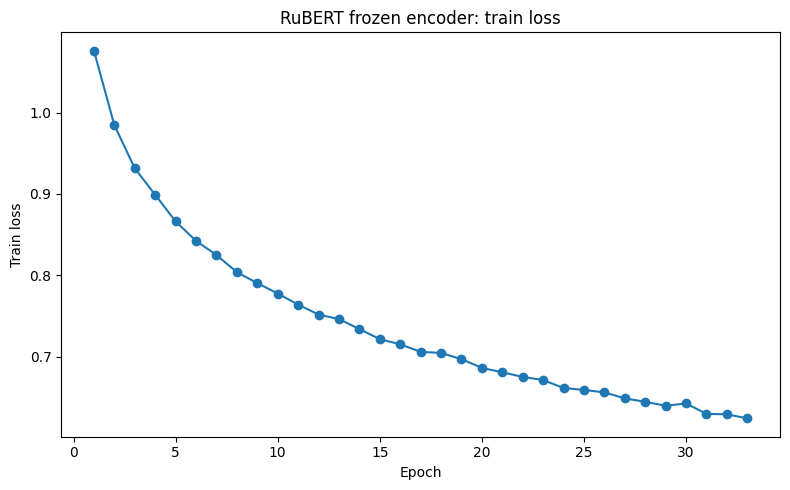

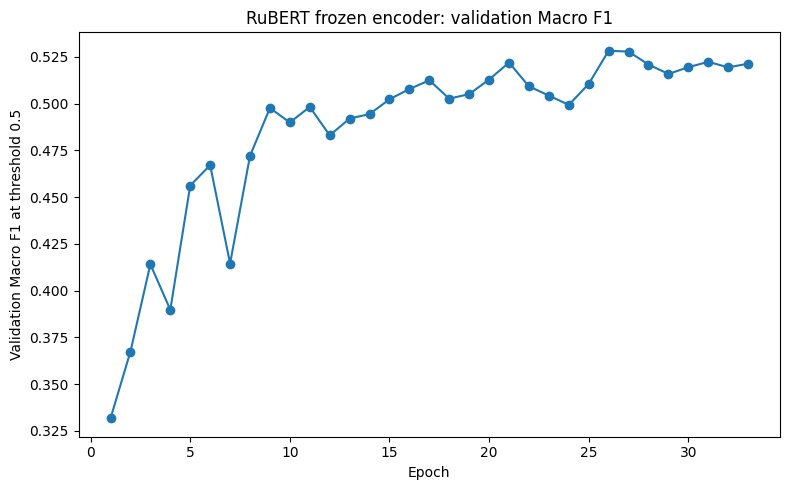

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("RuBERT frozen encoder: train loss")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "train_loss.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_macro_f1_at_0_5"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation Macro F1 at threshold 0.5")
plt.title("RuBERT frozen encoder: validation Macro F1")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "val_macro_f1.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Подбор thresholds на validation

In [17]:
def tune_thresholds_per_class(y_true, y_proba, label_names, n_grid=91):
    """
    Для каждого класса отдельно подбираем threshold по validation set.
    Golden set здесь не используется.
    """
    thresholds = np.linspace(0.05, 0.95, n_grid)
    best_thresholds = []
    rows = []

    for j, label in enumerate(label_names):
        best_t = 0.5
        best_f1 = -1.0
        best_p = 0.0
        best_r = 0.0

        for t in thresholds:
            pred = (y_proba[:, j] >= t).astype(int)
            p, r, f1, _ = precision_recall_fscore_support(
                y_true[:, j],
                pred,
                average="binary",
                zero_division=0,
            )
            if f1 > best_f1:
                best_f1 = f1
                best_t = t
                best_p = p
                best_r = r

        best_thresholds.append(best_t)
        rows.append({
            "class": label,
            "threshold": best_t,
            "val_precision": best_p,
            "val_recall": best_r,
            "val_f1": best_f1,
            "val_support": int(y_true[:, j].sum()),
        })

    return np.array(best_thresholds), pd.DataFrame(rows)


val_probs = predict_proba_head(model, X_val)
thresholds, thresholds_df = tune_thresholds_per_class(
    Y_val,
    val_probs,
    label_names,
    n_grid=N_THRESHOLD_GRID,
)

thresholds_path = OUTPUT_DIR / "rubert_frozen_encoder_thresholds.csv"
thresholds_df.to_csv(thresholds_path, index=False, encoding="utf-8-sig")

print("Saved:", thresholds_path)
thresholds_df.sort_values("val_f1")

Saved: /content/drive/MyDrive/MLops_project/project/data/labeled/rubert_frozen_encoder_experiment/rubert_frozen_encoder_thresholds.csv


,class,threshold,val_precision,val_recall,val_f1,val_support
1,Несоответствие карточке товара,0.67,0.400000,0.470588,0.432432,34
6,Проблема с комплектацией / упаковкой,0.42,0.416667,0.764706,0.539419,85
0,Другая проблема,0.51,0.437500,0.777778,0.560000,18
7,Проблема с размером / посадкой,0.52,0.476923,0.738095,0.579439,42
2,Положительный / нейтральный отзыв,0.68,0.571429,0.631579,0.600000,38
3,Проблема доставки / получения,0.59,0.518519,0.736842,0.608696,38
5,Проблема с качеством товара,0.46,0.520833,0.775194,0.623053,129
4,Проблема с возвратом,0.54,0.546512,0.796610,0.648276,59
8,Цена / ценность,0.64,0.694444,0.735294,0.714286,34


## 8. Финальная оценка на golden set

In [18]:
golden_probs = predict_proba_head(model, X_golden)

# Baseline: один threshold=0.5 для всех классов.
golden_pred_05 = (golden_probs >= 0.5).astype(int)

# Thresholded: пороги подобраны на validation split.
golden_pred_thr = (golden_probs >= thresholds.reshape(1, -1)).astype(int)

per_class_05, summary_05 = evaluate_binary_predictions(
    Y_golden,
    golden_pred_05,
    label_names,
    experiment_name="RuBERT_frozen_head__threshold_0_5",
)

per_class_thr, summary_thr = evaluate_binary_predictions(
    Y_golden,
    golden_pred_thr,
    label_names,
    experiment_name="RuBERT_frozen_head__thresholded_on_val",
)

per_class_metrics = pd.concat([per_class_05, per_class_thr], ignore_index=True)
summary_metrics = pd.DataFrame([summary_05, summary_thr])

per_class_path = OUTPUT_DIR / "per_class_metrics_rubert_frozen_encoder.csv"
summary_path = OUTPUT_DIR / "summary_metrics_rubert_frozen_encoder.csv"

per_class_metrics.to_csv(per_class_path, index=False, encoding="utf-8-sig")
summary_metrics.to_csv(summary_path, index=False, encoding="utf-8-sig")

print("Saved:", per_class_path)
print("Saved:", summary_path)

summary_metrics.sort_values("macro_f1", ascending=False)

Saved: /content/drive/MyDrive/MLops_project/project/data/labeled/rubert_frozen_encoder_experiment/per_class_metrics_rubert_frozen_encoder.csv
Saved: /content/drive/MyDrive/MLops_project/project/data/labeled/rubert_frozen_encoder_experiment/summary_metrics_rubert_frozen_encoder.csv


,experiment,macro_precision,macro_recall,macro_f1,micro_precision,micro_recall,micro_f1,weighted_precision,weighted_recall,weighted_f1
1,RuBERT_frozen_head__thresholded_on_val,0.510273,0.701470,0.564233,0.496403,0.676471,0.572614,0.515560,0.676471,0.555534
0,RuBERT_frozen_head__threshold_0_5,0.458608,0.755502,0.561548,0.467085,0.730392,0.569790,0.478392,0.730392,0.569364


In [19]:
# Таблица per-class метрик.
per_class_metrics.sort_values(["class", "f1"], ascending=[True, False]).reset_index(drop=True)

,experiment,class,precision,recall,f1,support,true_rate_golden,predicted_rate_golden
0,RuBERT_frozen_head__thresholded_on_val,Другая проблема,0.363636,0.800000,0.500000,5,0.034014,0.074830
1,RuBERT_frozen_head__threshold_0_5,Другая проблема,0.333333,0.800000,0.470588,5,0.034014,0.081633
2,RuBERT_frozen_head__threshold_0_5,Несоответствие карточке товара,0.433333,0.406250,0.419355,32,0.217687,0.204082
3,RuBERT_frozen_head__thresholded_on_val,Несоответствие карточке товара,0.500000,0.187500,0.272727,32,0.217687,0.081633
4,RuBERT_frozen_head__thresholded_on_val,Положительный / нейтральный отзыв,0.550000,0.523810,0.536585,21,0.142857,0.136054
5,RuBERT_frozen_head__threshold_0_5,Положительный / нейтральный отзыв,0.346939,0.809524,0.485714,21,0.142857,0.333333
6,RuBERT_frozen_head__threshold_0_5,Проблема доставки / получения,0.447368,0.944444,0.607143,18,0.122449,0.258503
7,RuBERT_frozen_head__thresholded_on_val,Проблема доставки / получения,0.454545,0.833333,0.588235,18,0.122449,0.224490
8,RuBERT_frozen_head__thresholded_on_val,Проблема с возвратом,0.653846,0.809524,0.723404,21,0.142857,0.176871
9,RuBERT_frozen_head__threshold_0_5,Проблема с возвратом,0.586207,0.809524,0.680000,21,0.142857,0.197279


In [20]:
# Удобные pivot-таблицы.
f1_pivot = per_class_metrics.pivot_table(index="class", columns="experiment", values="f1")
recall_pivot = per_class_metrics.pivot_table(index="class", columns="experiment", values="recall")
precision_pivot = per_class_metrics.pivot_table(index="class", columns="experiment", values="precision")

f1_pivot

experiment,RuBERT_frozen_head__threshold_0_5,RuBERT_frozen_head__thresholded_on_val
class,,
Другая проблема,0.470588,0.500000
Несоответствие карточке товара,0.419355,0.272727
Положительный / нейтральный отзыв,0.485714,0.536585
Проблема доставки / получения,0.607143,0.588235
Проблема с возвратом,0.680000,0.723404
Проблема с качеством товара,0.633663,0.589286
Проблема с комплектацией / упаковкой,0.500000,0.525000
Проблема с размером / посадкой,0.724138,0.714286
Цена / ценность,0.533333,0.628571


## 9. Графики

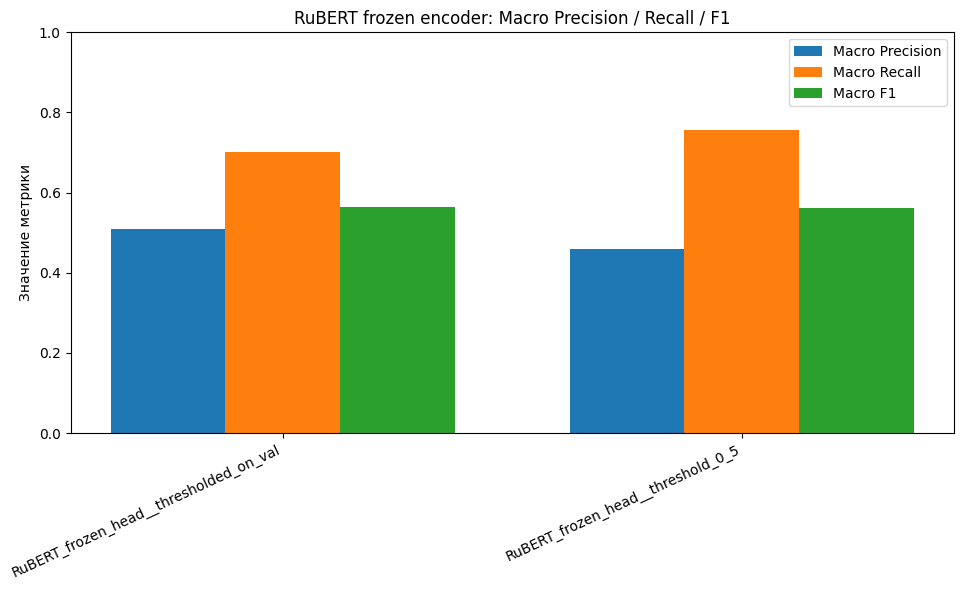

In [21]:
# График 1: macro precision / recall / F1.
plot_df = summary_metrics.copy().sort_values("macro_f1", ascending=False)

x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(max(10, 2.5 * len(plot_df)), 6))
plt.bar(x - width, plot_df["macro_precision"], width, label="Macro Precision")
plt.bar(x, plot_df["macro_recall"], width, label="Macro Recall")
plt.bar(x + width, plot_df["macro_f1"], width, label="Macro F1")
plt.xticks(x, plot_df["experiment"], rotation=25, ha="right")
plt.ylim(0, 1)
plt.ylabel("Значение метрики")
plt.title("RuBERT frozen encoder: Macro Precision / Recall / F1")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "macro_precision_recall_f1.png", dpi=200, bbox_inches="tight")
plt.show()

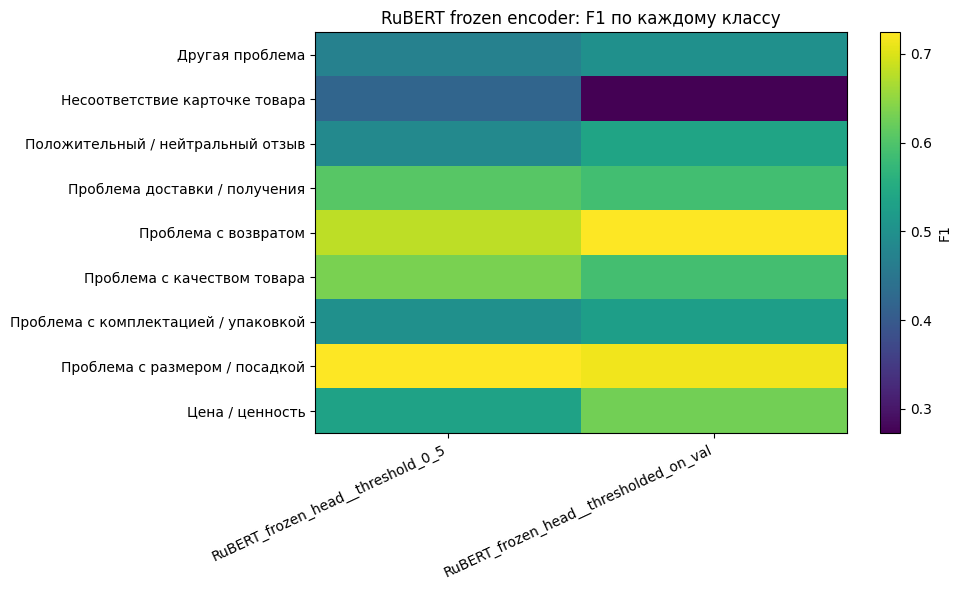

In [22]:
# График 2: heatmap F1 по классам.
heatmap_df = f1_pivot.copy().fillna(0)

plt.figure(figsize=(max(10, 1.5 * heatmap_df.shape[1]), max(6, 0.45 * heatmap_df.shape[0])))
plt.imshow(heatmap_df.values, aspect="auto")
plt.colorbar(label="F1")
plt.xticks(np.arange(heatmap_df.shape[1]), heatmap_df.columns, rotation=25, ha="right")
plt.yticks(np.arange(heatmap_df.shape[0]), heatmap_df.index)
plt.title("RuBERT frozen encoder: F1 по каждому классу")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "per_class_f1_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

Лучшая версия: RuBERT_frozen_head__thresholded_on_val


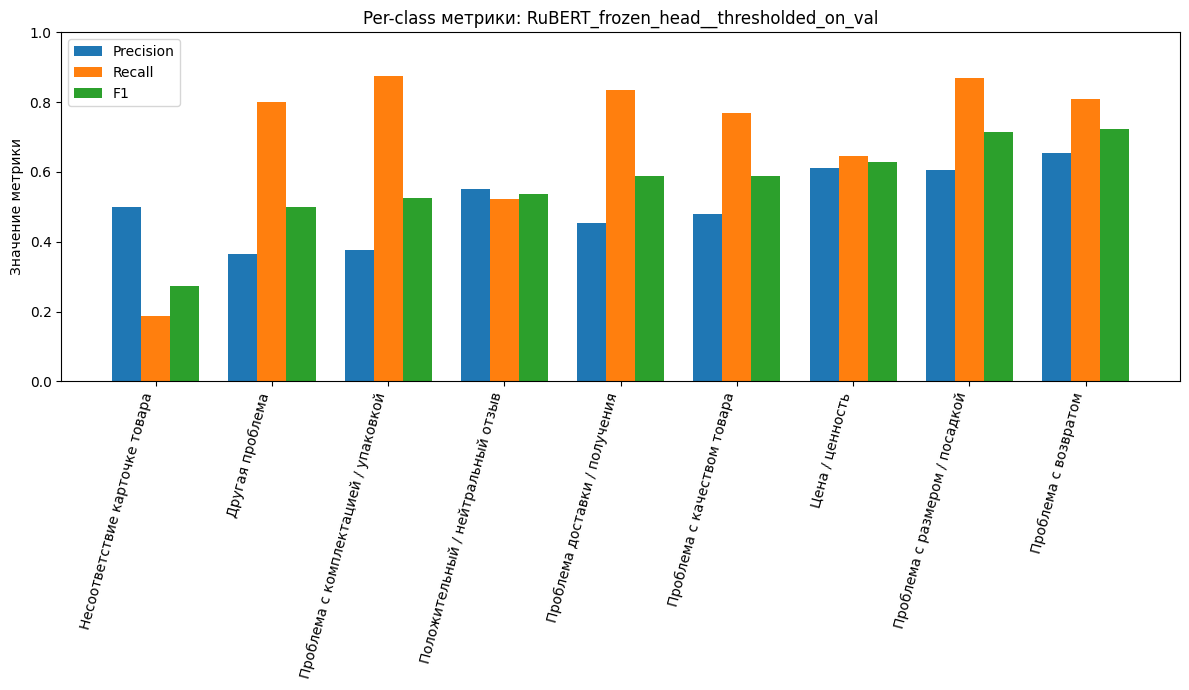

,experiment,class,precision,recall,f1,support,true_rate_golden,predicted_rate_golden
10,RuBERT_frozen_head__thresholded_on_val,Несоответствие карточке товара,0.500000,0.187500,0.272727,32,0.217687,0.081633
9,RuBERT_frozen_head__thresholded_on_val,Другая проблема,0.363636,0.800000,0.500000,5,0.034014,0.074830
15,RuBERT_frozen_head__thresholded_on_val,Проблема с комплектацией / упаковкой,0.375000,0.875000,0.525000,24,0.163265,0.380952
11,RuBERT_frozen_head__thresholded_on_val,Положительный / нейтральный отзыв,0.550000,0.523810,0.536585,21,0.142857,0.136054
12,RuBERT_frozen_head__thresholded_on_val,Проблема доставки / получения,0.454545,0.833333,0.588235,18,0.122449,0.224490
14,RuBERT_frozen_head__thresholded_on_val,Проблема с качеством товара,0.478261,0.767442,0.589286,43,0.292517,0.469388
17,RuBERT_frozen_head__thresholded_on_val,Цена / ценность,0.611111,0.647059,0.628571,17,0.115646,0.122449
16,RuBERT_frozen_head__thresholded_on_val,Проблема с размером / посадкой,0.606061,0.869565,0.714286,23,0.156463,0.224490
13,RuBERT_frozen_head__thresholded_on_val,Проблема с возвратом,0.653846,0.809524,0.723404,21,0.142857,0.176871


In [23]:
# График 3: precision / recall / F1 по классам для лучшей версии.
best_exp = summary_metrics.sort_values("macro_f1", ascending=False).iloc[0]["experiment"]
print("Лучшая версия:", best_exp)

best_per_class = per_class_metrics[per_class_metrics["experiment"] == best_exp].copy()
best_per_class = best_per_class.sort_values("f1", ascending=True)

x = np.arange(len(best_per_class))
width = 0.25

plt.figure(figsize=(max(12, 0.65 * len(best_per_class)), 7))
plt.bar(x - width, best_per_class["precision"], width, label="Precision")
plt.bar(x, best_per_class["recall"], width, label="Recall")
plt.bar(x + width, best_per_class["f1"], width, label="F1")
plt.xticks(x, best_per_class["class"], rotation=75, ha="right")
plt.ylim(0, 1)
plt.ylabel("Значение метрики")
plt.title(f"Per-class метрики: {best_exp}")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "best_version_per_class_metrics.png", dpi=200, bbox_inches="tight")
plt.show()

best_per_class

## 10. Сохранение модели и артефактов

In [24]:
# Сохраняем голову, labels, thresholds и конфиг.
model_path = MODEL_DIR / "rubert_frozen_linear_head.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": input_dim,
    "n_labels": n_labels,
    "label_names": label_names,
    "thresholds": thresholds,
    "rubert_model_name": RUBERT_MODEL_NAME,
    "max_length": MAX_LENGTH,
    "pooling": "cls",
    "dropout": DROPOUT,
}, model_path)

joblib.dump(mlb, MODEL_DIR / "multilabel_binarizer.joblib")

config = {
    "rubert_model_name": RUBERT_MODEL_NAME,
    "max_length": MAX_LENGTH,
    "encode_batch_size": ENCODE_BATCH_SIZE,
    "head_batch_size": HEAD_BATCH_SIZE,
    "epochs": EPOCHS,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "dropout": DROPOUT,
    "patience": PATIENCE,
    "best_epoch": int(best_epoch),
    "best_val_macro_f1_at_0_5": float(best_val_macro_f1),
    "labels": label_names,
}

with open(MODEL_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print("Модель:", model_path)
print("MLB:", MODEL_DIR / "multilabel_binarizer.joblib")
print("Config:", MODEL_DIR / "config.json")
print("Thresholds:", thresholds_path)
print("Summary metrics:", summary_path)
print("Per-class metrics:", per_class_path)
print("Графики:", PLOTS_DIR)

Модель: /content/drive/MyDrive/MLops_project/project/data/labeled/rubert_frozen_encoder_experiment/trained_model/rubert_frozen_linear_head.pt
MLB: /content/drive/MyDrive/MLops_project/project/data/labeled/rubert_frozen_encoder_experiment/trained_model/multilabel_binarizer.joblib
Config: /content/drive/MyDrive/MLops_project/project/data/labeled/rubert_frozen_encoder_experiment/trained_model/config.json
Thresholds: /content/drive/MyDrive/MLops_project/project/data/labeled/rubert_frozen_encoder_experiment/rubert_frozen_encoder_thresholds.csv
Summary metrics: /content/drive/MyDrive/MLops_project/project/data/labeled/rubert_frozen_encoder_experiment/summary_metrics_rubert_frozen_encoder.csv
Per-class metrics: /content/drive/MyDrive/MLops_project/project/data/labeled/rubert_frozen_encoder_experiment/per_class_metrics_rubert_frozen_encoder.csv
Графики: /content/drive/MyDrive/MLops_project/project/data/labeled/rubert_frozen_encoder_experiment/plots


## 11. Как читать результат

Главная таблица — `summary_metrics`.

Смотри:

- `macro_f1` — среднее качество по классам;
- `macro_recall` — насколько хорошо модель находит классы;
- `macro_precision` — насколько редко ставит лишние классы.

Потом смотри `best_per_class`: там видно, какие классы модель проваливает.

Если `thresholded_on_val` лучше обычного `threshold_0_5`, значит отдельные пороги по классам реально помогли.
Если хуже — можно оставить простой порог 0.5.